In [33]:
from sympy import N


def clean_data(df):
    # 欠損値の補填
    df.loc[df["性別"] == "male", "年齢"] = df.loc[df["性別"] == "male", "年齢"].fillna(df.loc[df["性別"] == "male", "年齢"].median())
    df.loc[df["性別"] == "female", "年齢"] = df.loc[df["性別"] == "female", "年齢"].fillna(df.loc[df["性別"] == "female", "年齢"].median())
    
    # 乗船した港は、そこまで生存に大きくかかわらないと思うから、不明とする。
    df["乗船した港"] = df["乗船した港"].fillna("不明")

    return df


In [34]:
# 初期処理

# ライブラリのインポート
import pandas as pd # Pandasをインポート
import matplotlib.pyplot as plt # Matplotlibをインポート
import japanize_matplotlib

# 学習データを読み込み、データフレームとして格納
df = pd.read_csv("data/train.csv")
old_col_name = df.columns.tolist()
new_col_name = ["id", "生存結果", "客室のクラス", "性別", "年齢", "兄弟・配偶者の数", "両親・子供の数", "運賃", "乗船した港"]
# 列名を変更
df.columns = new_col_name

df_test = pd.read_csv("data/test.csv")
df_test.columns = ["id", "客室のクラス", "性別", "年齢", "兄弟・配偶者の数", "両親・子供の数", "運賃", "乗船した港"]

df_train = clean_data(df)
df_test = clean_data(df_test)

print(df.head())
print(df_test.head())


   id  生存結果  客室のクラス      性別    年齢  兄弟・配偶者の数  両親・子供の数       運賃 乗船した港
0   3     1       1  female  35.0         1        0  53.1000     S
1   4     0       3    male  35.0         0        0   8.0500     S
2   7     0       3    male   2.0         3        1  21.0750     S
3   9     1       2  female  14.0         1        0  30.0708     C
4  11     1       1  female  58.0         0        0  26.5500     S
   id  客室のクラス      性別    年齢  兄弟・配偶者の数  両親・子供の数       運賃 乗船した港
0   0       3    male  22.0         1        0   7.2500     S
1   1       1  female  38.0         1        0  71.2833     C
2   2       3  female  26.0         0        0   7.9250     S
3   5       3    male  29.0         0        0   8.4583     Q
4   6       1    male  54.0         0        0  51.8625     S


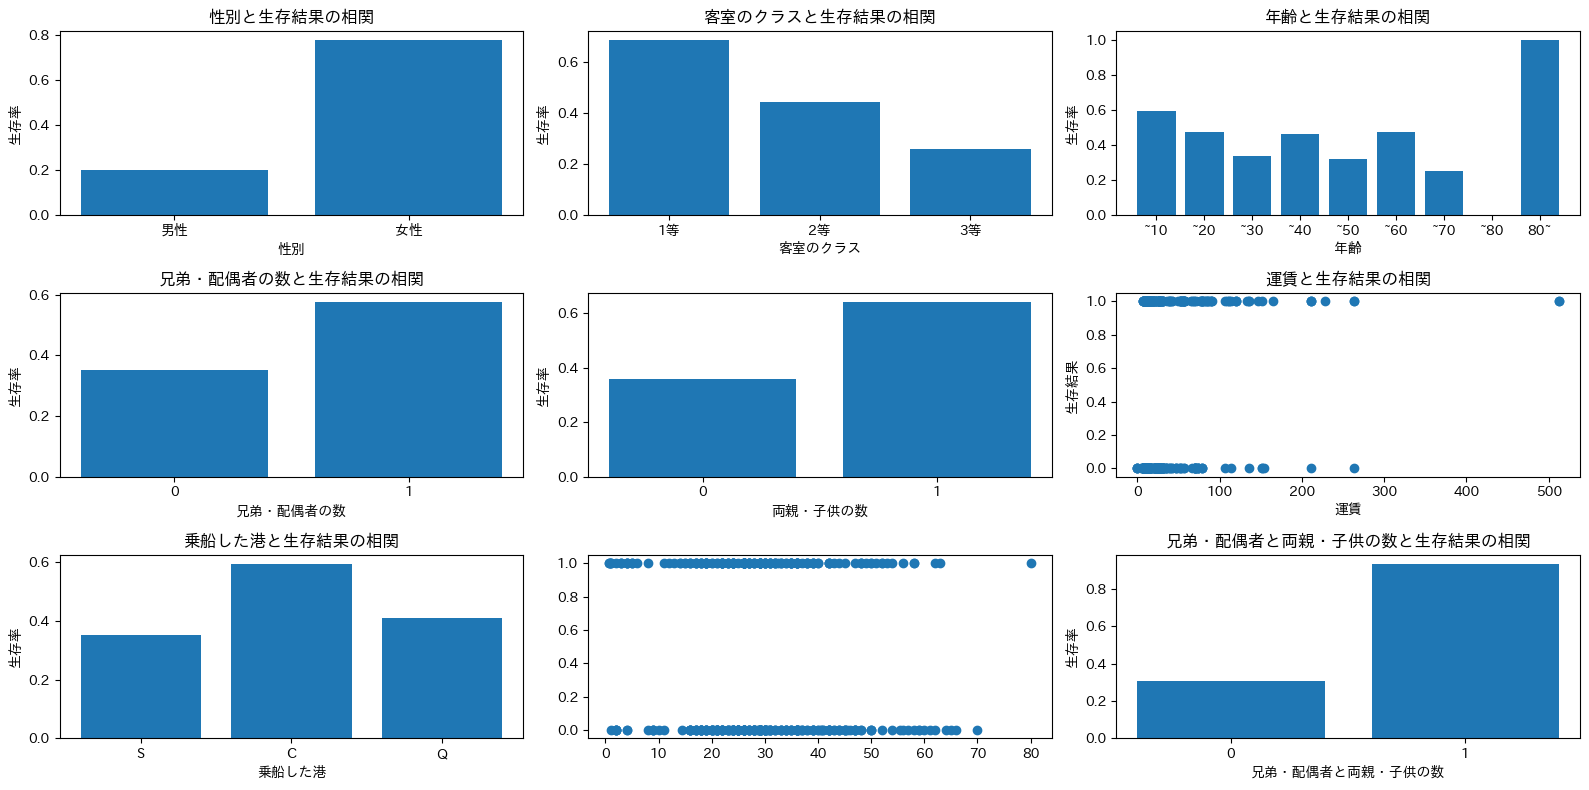

In [35]:
# データの可視化と確認
# 各データと生存結果の相関を可視化して確認
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
# 性別と生存結果の相関を確認
# 性別ごとの生存率を出す
male_survived_rate = len(df_train.loc[(df_train["性別"] == "male") & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["性別"] == "male")]) # 男性の生存率
female_survived_rate = len(df_train.loc[(df_train["性別"] == "female") & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["性別"] == "female")]) # 女性の生存率
# 性別ごとの生存率を出す
axes[0, 0].bar(["男性", "女性"], [male_survived_rate, female_survived_rate])
axes[0, 0].set_xlabel("性別")
axes[0, 0].set_ylabel("生存率")
axes[0, 0].set_title("性別と生存結果の相関")
# 客室のクラスと生存結果の相関を確認
# 客室のクラスごとの生存率を出す
first_class_survived_rate = len(df_train.loc[(df_train["客室のクラス"] == 1) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["客室のクラス"] == 1)]) # 1等客室の生存率
second_class_survived_rate = len(df_train.loc[(df_train["客室のクラス"] == 2) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["客室のクラス"] == 2)]) # 2等客室の生存率
third_class_survived_rate = len(df_train.loc[(df_train["客室のクラス"] == 3) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["客室のクラス"] == 3)]) # 3等客室の生存率
# 客室のクラスごとの生存率を出す
axes[0, 1].bar(["1等", "2等", "3等"], [first_class_survived_rate, second_class_survived_rate, third_class_survived_rate]) 
axes[0, 1].set_xlabel("客室のクラス")
axes[0, 1].set_ylabel("生存率")
axes[0, 1].set_title("客室のクラスと生存結果の相関")

# 年齢と生存結果の相関を確認
# 10歳ごとに区切って、生存率を出す
age0_10_survived_rate = len(df_train.loc[(df_train["年齢"] >= 0) & (df_train["年齢"] < 10) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 0) & (df_train["年齢"] < 10)]) # 0~10歳の生存率
age10_20_survived_rate = len(df_train.loc[(df_train["年齢"] >= 10) & (df_train["年齢"] < 20) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 10) & (df_train["年齢"] < 20)]) # 10~20歳の生存率
age20_30_survived_rate = len(df_train.loc[(df_train["年齢"] >= 20) & (df_train["年齢"] < 30) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 20) & (df_train["年齢"] < 30)]) # 20~30歳の生存率
age30_40_survived_rate = len(df_train.loc[(df_train["年齢"] >= 30) & (df_train["年齢"] < 40) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 30) & (df_train["年齢"] < 40)]) # 30~40歳の生存率
age40_50_survived_rate = len(df_train.loc[(df_train["年齢"] >= 40) & (df_train["年齢"] < 50) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 40) & (df_train["年齢"] < 50)]) # 40~50歳の生存率
age50_60_survived_rate = len(df_train.loc[(df_train["年齢"] >= 50) & (df_train["年齢"] < 60) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 50) & (df_train["年齢"] < 60)]) # 50~60歳の生存率
age60_70_survived_rate = len(df_train.loc[(df_train["年齢"] >= 60) & (df_train["年齢"] < 70) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 60) & (df_train["年齢"] < 70)]) # 60~70歳の生存率
age70_80_survived_rate = len(df_train.loc[(df_train["年齢"] >= 70) & (df_train["年齢"] < 80) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 70) & (df_train["年齢"] < 80)]) # 70~80歳の生存率
age80_inf_survived_rate = len(df_train.loc[(df_train["年齢"] >= 80) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["年齢"] >= 80)]) # 80歳以上の生存率
axes[0, 2].bar(["~10", "~20", "~30", "~40", "~50", "~60", "~70", "~80", "80~"], [age0_10_survived_rate, age10_20_survived_rate, age20_30_survived_rate, age30_40_survived_rate, age40_50_survived_rate, age50_60_survived_rate, age60_70_survived_rate, age70_80_survived_rate, age80_inf_survived_rate])
axes[0, 2].set_xlabel("年齢")
axes[0, 2].set_ylabel("生存率")
axes[0, 2].set_title("年齢と生存結果の相関")
# 兄弟・配偶者の数と生存結果の相関を確認
# 0かそうでないかで生存率を出す。
sibsp_0_survived_rate = len(df_train.loc[(df_train["兄弟・配偶者の数"] == 0) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["兄弟・配偶者の数"] == 0)]) # 兄弟・配偶者の数が0の生存率
sibsp_1_survived_rate = len(df_train.loc[(df_train["兄弟・配偶者の数"] == 1) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["兄弟・配偶者の数"] == 1)]) # 兄弟・配偶者の数が1の生存率
axes[1, 0].bar(["0", "1"], [sibsp_0_survived_rate, sibsp_1_survived_rate])
axes[1, 0].set_xlabel("兄弟・配偶者の数")
axes[1, 0].set_ylabel("生存率")
axes[1, 0].set_title("兄弟・配偶者の数と生存結果の相関")
# 両親・子供の数と生存結果の相関を確認
# 0かそうでないかで生存率を出す。
parch_0_survived_rate = len(df_train.loc[(df_train["両親・子供の数"] == 0) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["両親・子供の数"] == 0)]) # 両親・子供の数が0の生存率
parch_1_survived_rate = len(df_train.loc[(df_train["両親・子供の数"] == 1) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["両親・子供の数"] == 1)]) # 両親・子供の数が1の生存率
axes[1, 1].bar(["0", "1"], [parch_0_survived_rate, parch_1_survived_rate])
axes[1, 1].set_xlabel("両親・子供の数")
axes[1, 1].set_ylabel("生存率")
# 運賃と生存結果の相関を確認（散布図でできるか）
axes[1, 2].scatter(df_train["運賃"], df_train["生存結果"])
axes[1, 2].set_xlabel("運賃")
axes[1, 2].set_ylabel("生存結果")
axes[1, 2].set_title("運賃と生存結果の相関")
# 乗船した港と生存結果の相関を確認
# 乗船した港ごとの生存率を出す
embarked_S_survived_rate = len(df_train.loc[(df_train["乗船した港"] == "S") & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["乗船した港"] == "S")]) # S港の生存率
embarked_C_survived_rate = len(df_train.loc[(df_train["乗船した港"] == "C") & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["乗船した港"] == "C")]) # C港の生存率
embarked_Q_survived_rate = len(df_train.loc[(df_train["乗船した港"] == "Q") & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["乗船した港"] == "Q")]) # Q港の生存率
axes[2, 0].bar(["S", "C", "Q"], [embarked_S_survived_rate, embarked_C_survived_rate, embarked_Q_survived_rate])
axes[2, 0].set_xlabel("乗船した港")
axes[2, 0].set_ylabel("生存率")
axes[2, 0].set_title("乗船した港と生存結果の相関")
# 年齢と生存結果の散布図
axes[2, 1].scatter(df_train["年齢"], df_train["生存結果"])

# 兄弟・配偶者と両親・子供の数が両方0の生存率と1以上の生存率を出す。
sibsp_parch_0_survived_rate = len(df_train.loc[(df_train["兄弟・配偶者の数"] == 0) & (df_train["両親・子供の数"] == 0) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["兄弟・配偶者の数"] == 0) & (df_train["両親・子供の数"] == 0)]) # 兄弟・配偶者と両親・子供の数が両方0の生存率
sibsp_parch_1_survived_rate = len(df_train.loc[(df_train["兄弟・配偶者の数"] >= 1) | (df_train["両親・子供の数"] >= 1) & (df_train["生存結果"] == 1)]) / len(df_train.loc[(df_train["兄弟・配偶者の数"] >= 1) | (df_train["両親・子供の数"] >= 1)]) # 兄弟・配偶者と両親・子供の数が1以上の生存率
axes[2, 2].bar(["0", "1"], [sibsp_parch_0_survived_rate, sibsp_parch_1_survived_rate])
axes[2, 2].set_xlabel("兄弟・配偶者と両親・子供の数")
axes[2, 2].set_ylabel("生存率")
axes[2, 2].set_title("兄弟・配偶者と両親・子供の数と生存結果の相関")

plt.tight_layout()
plt.show()

In [39]:
# 決定木による分析
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np


def tree_model2(df):
    df["性別"] = df["性別"].map({"male": 0, "female": 1})
    df = pd.get_dummies(df, columns=["乗船した港"])
    df["家族多"] = (df["兄弟・配偶者の数"] >= 1) & (df["両親・子供の数"] >= 1)
    if not ("乗船した港_不明" in df.columns):
        df["乗船した港_不明"] = False
    return df

# まず最初のモデル用のデータをコピー
df_copy_model2 = df_train.copy()
df_copy_model2 = tree_model2(df_copy_model2)
#print(df_copy_model2.head())

# データの分割
X2 = df_copy_model2.drop("生存結果", axis=1).to_numpy()
y2 = df_copy_model2["生存結果"].to_numpy()
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# モデルの作成
model2 = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced")

# モデルの訓練
model2.fit(X_train2, y_train2)

# モデルの評価
y_pred2 = model2.predict(X_test2)
y_pred2

print(classification_report(y_test2, y_pred2))

print(f"train:{model2.score(X_train2, y_train2)}")
print(f"test:{model2.score(X_test2, y_test2)}")

# 4. testデータで予測
df_test_model2 = tree_model2(df_test.copy())
print(df_copy_model2.head())
print(df_test_model2.head())

predictions_rf = model2.predict(df_test_model2.to_numpy())

# 5. 予測結果の確認
print(f"\n生存予測: {predictions_rf.sum()}人")
print(f"死亡予測: {(predictions_rf == 0).sum()}人")

# 提出ファイル作成
submission_rf = pd.DataFrame({
    'id': df_test_model2['id'],
    'Survived': predictions_rf
})
print(submission_rf.head())

submission_rf.to_csv('submission_rf.csv', header=False, index=False)
print("\nsubmission_rf.csv を保存しました!")

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        56
           1       0.79      0.70      0.74        33

    accuracy                           0.82        89
   macro avg       0.81      0.79      0.80        89
weighted avg       0.82      0.82      0.82        89

train:0.8258426966292135
test:0.8202247191011236
   id  生存結果  客室のクラス  性別    年齢  兄弟・配偶者の数  両親・子供の数       運賃  乗船した港_C  乗船した港_Q  \
0   3     1       1   1  35.0         1        0  53.1000    False    False   
1   4     0       3   0  35.0         0        0   8.0500    False    False   
2   7     0       3   0   2.0         3        1  21.0750    False    False   
3   9     1       2   1  14.0         1        0  30.0708     True    False   
4  11     1       1   1  58.0         0        0  26.5500    False    False   

   乗船した港_S  乗船した港_不明    家族多  
0     True     False  False  
1     True     False  False  
2     True     False   True  
3    False     False  False  